In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def detect_lanes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    edges = cv2.Canny(blurred, 50, 150)
    
    height, width = edges.shape
    mask = np.zeros_like(edges)
    
    polygon = np.array([[
    (40, height),
    (width//2 - 55, int(height*0.58)),
    (width//2 + 55, int(height*0.58)),
    (width - 40, height)
        ]], dtype=np.int32)

    cv2.fillPoly(mask, polygon, 255)
    
    masked_edges = cv2.bitwise_and(edges, mask)
    
    lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, 100, minLineLength=50, maxLineGap=50)
    
    return lines

In [3]:
def draw_lanes(image, lines):
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 3)
    return image

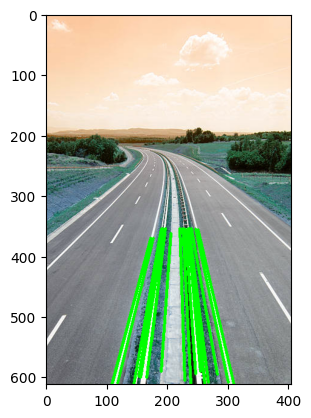

In [4]:
img = cv2.imread('images.jpg')

lines = detect_lanes(img)
result = draw_lanes(img, lines)

plt.imshow(result)